In [1]:
import pandas as pd

# Read the CSV file into a DataFrame
df = pd.read_csv('penguin_data.csv')
X = df.values[:, 1:]
y = df.values[:, 0]

In [15]:
from sklearn.model_selection import ShuffleSplit 
from sklearn.preprocessing import StandardScaler

ss = ShuffleSplit(test_size=0.3, random_state=0)

train_id, test_id = next(ss.split(X))
X_train, X_test = X[train_id], X[test_id]
y_train, y_test = y[train_id], y[test_id]

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)


In [16]:
from sklearn import svm
from sklearn.metrics import classification_report
clf = svm.SVC(gamma=0.01)
clf.fit(X_train_std, y_train)
y_pred = clf.predict(X_test_std)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98        50
         1.0       1.00      0.88      0.94        17
         2.0       1.00      1.00      1.00        36

    accuracy                           0.98       103
   macro avg       0.99      0.96      0.97       103
weighted avg       0.98      0.98      0.98       103



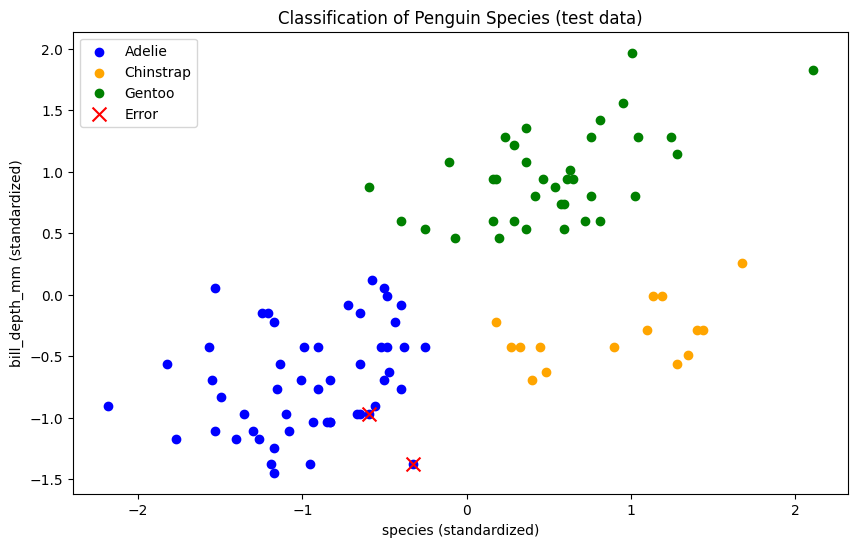

-0.06854779972072728


In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(x=X_test_std[y_pred==0][:, 0], y=X_test_std[y_pred==0][:, 2], color='blue', label='Adelie')
plt.scatter(x=X_test_std[y_pred==1][:, 0], y=X_test_std[y_pred==1][:, 2], color='orange', label='Chinstrap')
plt.scatter(x=X_test_std[y_pred==2][:, 0], y=X_test_std[y_pred==2][:, 2], color='green', label='Gentoo')
plt.scatter(x=X_test_std[y_pred!=y_test][:, 0], y=X_test_std[y_pred!=y_test][:, 2], color='red', label='Error', marker='x', s=100)
plt.title('Classification of Penguin Species (test data)')
plt.xlabel(df.columns.values[0] + ' (standardized)')
plt.ylabel(df.columns.values[2] + ' (standardized)')
plt.legend()
plt.show()
print(max(X_test_std[y_pred==2][:, 1]))